# Load network
Build edges, nodes, and adjacency list from the input file. 

In [14]:
import numpy as np
import networkx as nx
import pandas as pd
import random

random.seed(42)

graph = nx.Graph() # undirected
edges_positive = np.loadtxt("train.csv", delimiter=",", dtype=int).tolist()
edges_positive = set(tuple((u, v)) for u, v in edges_positive)
n_pos = len(edges_positive)
edge_exists = lambda u, v: (u, v) in edges_positive # assumed (u,v) sampled from edges if exists

graph.add_edges_from(edges_positive)
edges_neg = random.sample(list(nx.non_edges(graph)), 36000) # sample 1:9 ratio of negative edges
graph.add_edges_from(edges_neg)

print(f"# of nodes: {graph.number_of_nodes()}")
print(f"# of undirected edges: {graph.number_of_edges()} (positive: {n_pos}, negative: {len(edges_neg)})")
print(f"degrees = min: {np.min(list(dict(graph.degree()).values()))}, max: {np.max(list(dict(graph.degree()).values()))}, p75: {np.percentile(list(dict(graph.degree()).values()), 75):.2f}, median: {np.median(list(dict(graph.degree()).values())):.2f}")

# of nodes: 2485
# of undirected edges: 40969 (positive: 4969, negative: 36000)
degrees = min: 14, max: 193, p75: 37.00, median: 32.00


## Setup visualizations

In [ ]:
import os
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

output_dir = 'plots'
os.makedirs(output_dir, exist_ok=True)

plot_counter = 1
def show_and_save_plot():
    global plot_counter
    fig = plt.gcf()
    title = fig._suptitle.get_text() if fig._suptitle else plt.gca().get_title()
    if not title:
        title = f"plot_{plot_counter:03d}"
        plot_counter += 1
    filename = "".join(c if c.isalnum() or c in "._-" else "_" for c in title).replace(" ", "_") + ".png"
    plt.savefig(f"{output_dir}/{filename}", dpi=300, bbox_inches='tight', transparent=True)
    
plt.show = show_and_save_plot

: 

: 

In [ ]:
def display_top_edges(new_edges_dict, name, k=10, save=True):
    """Display top-K edges based on a link prediction scoring measure and save them to a file."""
    top = sorted(new_edges_dict.items(), key=lambda x: x[1], reverse=True)[:k]
    print(f"Top {k} edges by {name}:")
    for (node1, node2), score in top:
        print(f"Edge ({node1}, {node2}): {score:.4f}")

    nodes_, scores = zip(*top)
    plt.figure(figsize=(9, 4))
    plt.bar(range(len(top)), scores, color="tomato")
    plt.xticks(range(len(top)), nodes_)
    plt.grid(True, alpha=0.3, axis="y")
    plt.xlabel("Edge #")
    plt.ylabel("Score")
    plt.title(f"Top {k} edges by {name}")
    plt.tight_layout()
    plt.show()

    if save:
        with open("results.txt", "a") as f:
            f.write(" ".join(f"({node1}, {node2})" for (node1, node2), _ in top) + "\n")

: 

: 

# Plotting the graph

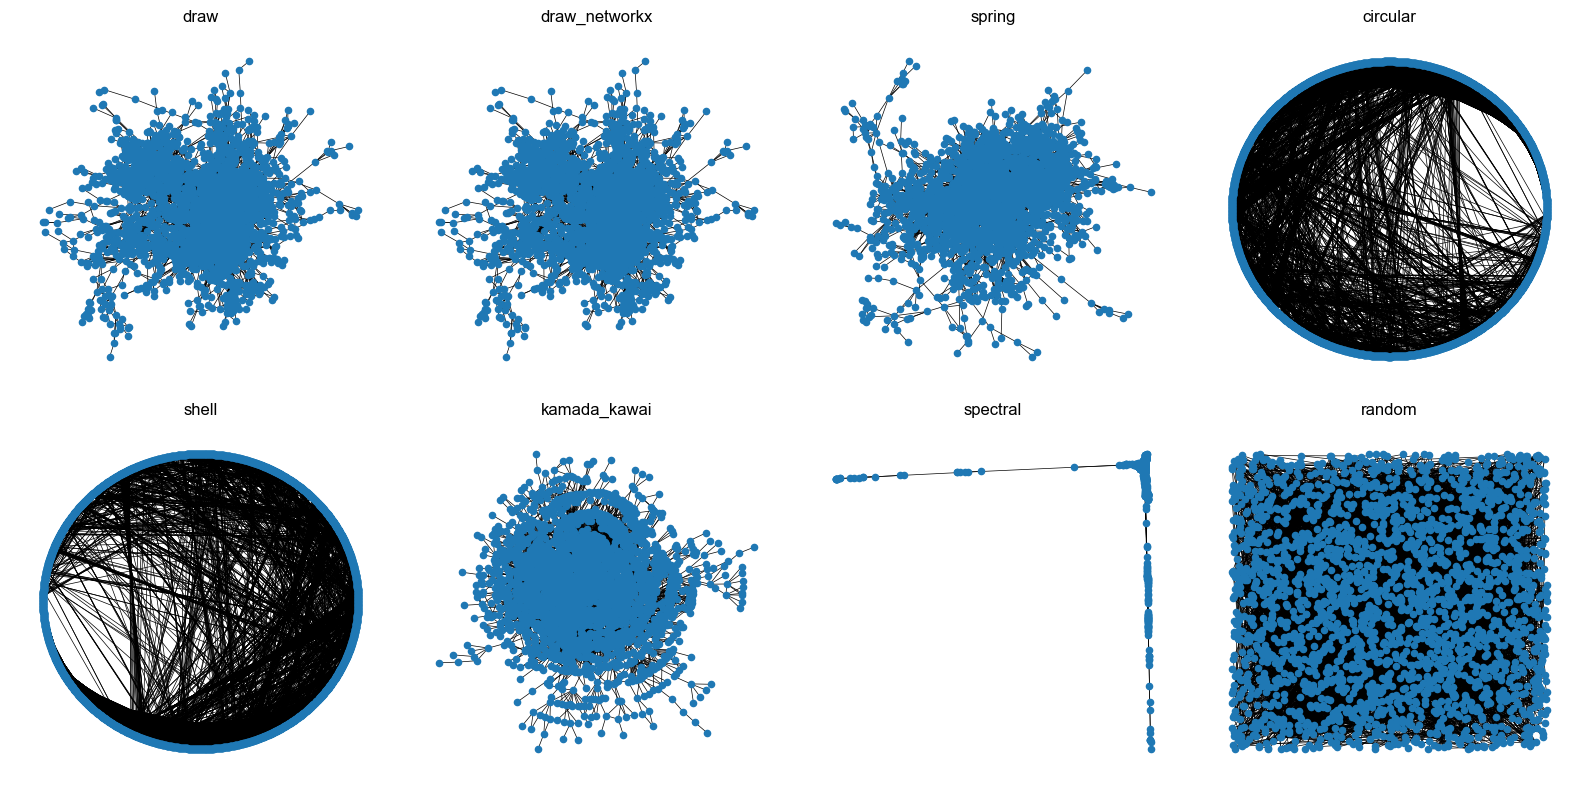

: 

: 

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

plots = [
    ("draw", lambda ax: nx.draw(graph, pos=pos, ax=ax, node_size=20, width=0.5)),
    ("draw_networkx", lambda ax: nx.draw_networkx(graph, pos=pos, ax=ax, node_size=20, width=0.5, with_labels=False)),
    ("spring", lambda ax: nx.draw_spring(graph, ax=ax, node_size=20, width=0.5)),
    ("circular", lambda ax: nx.draw_circular(graph, ax=ax, node_size=20, width=0.5)),
    ("shell", lambda ax: nx.draw_shell(graph, ax=ax, node_size=20, width=0.5)),
    ("kamada_kawai", lambda ax: nx.draw_kamada_kawai(graph, ax=ax, node_size=20, width=0.5)),
    ("spectral", lambda ax: nx.draw_spectral(graph, ax=ax, node_size=20, width=0.5)),
    ("random", lambda ax: nx.draw_random(graph, ax=ax, node_size=20, width=0.5)),
]

for ax, (title, plot_fn) in zip(axes, plots):
    plot_fn(ax)
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Link prediction
The idea is to create a **scoring function** $\sigma(x, y)$ that measures the **proximity** between two nodes. 

The **top-k** scoring pairs of nodes are the candidate for having a new edge, if they are not already connected.

There are several *families* of scoring methods:

## Neighborhood-based (degree)
1. **Common Neighbors**: the more common neighbors the more similar
$$
\sigma(x, y) = |N(x) \cap N(y)|
$$

2. **Jaccard Similarity**: ...but normalizes by the total number of neighbors
$$
\sigma(x, y) = \frac{|N(x) \cap N(y)|}{|N(x) \cup N(y)|}
$$

3. **Cosine Similarity**: ...but normalizes by the geometric mean of the number of neighbors
$$
\sigma(x, y) = \frac{|N(x) \cap N(y)|}{\sqrt{|N(x)| \cdot |N(y)|}}
$$

4. **Adamic and Adar**: gives more weight to common neighbors with fewer connections
$$
\sigma(x, y) = \sum_{z \in N(x) \cap N(y)} \frac{1}{\log |N(z)|}
$$

5. **Preferential Attachment**: the more _(common or not)_ neighbors the more similar
$$
\sigma(x, y) = |N(x)| \cdot |N(y)|
$$

> To avoid having zero similarity, add the node *itself* to its neighbors.

## Random Walk-based (distance)
1. **Katz 1953**: the more short paths exist between them, the more similar
$$
\sigma(x, y) = \sum_{l=1}^{\infty} \beta^l |\text{paths}_{x, y}^{(l)}| = \sum \beta^l (A^l)_{xy}
$$

2. **Personalized PageRank**: the more likely to reach each other in a random walk, the more similar
$$
\sigma(x, y) = r_x(y) + r_y(x)
$$

## Community-based (clusters)
1. **Spectral Clustering**: the closer the eigenvector embedding of the nodes in the graph Laplacian, the more similar

$$
\sigma(x, y) = \|\hat{x} - \hat{y}\|_2
$$

2. **Modularity Maximization**: the closer the eigenvector embedding of the node in the graph Modularity, the more similar

$$
\sigma(x, y) = \|\hat{x} - \hat{y}\|_2
$$

## Embedding-based
- TBD

## Method 1: Common Neighbors (degree-based)

In [28]:
as_scores = lambda edges_scores_dict: pd.DataFrame({
    "edge": list(edges_scores_dict.keys()),
    "score": list(edges_scores_dict.values()),
    "exists": [edge_exists(u, v) for u, v in edges_scores_dict.keys()]
}).sort_values(by="score", ascending=False).reset_index(drop=True)

common_neighs = {}
for u, v in edges_positive:
    common_neighs[(u, v)] = len(list(nx.common_neighbors(graph, u, v)))
scores = as_scores(common_neighs)
print(scores)

             edge  score  exists
0        (0, 768)     16    True
1       (118, 85)     13    True
2        (51, 49)     13    True
3        (0, 781)     13    True
4       (13, 118)     12    True
...           ...    ...     ...
4964  (653, 1641)      0    True
4965   (2376, 27)      0    True
4966  (446, 2113)      0    True
4967  (696, 1338)      0    True
4968  (717, 2335)      0    True

[4969 rows x 3 columns]


# Evaluation

| | Predicted Positive | Predicted Negative |
|---|:-:|:-:|
| **Actual Positive** | TP | FN |
| **Actual Negative** | FP | TN |

* **TP**: edge exists and is predicted
* **FP**: edge *does not* exist but is predicted
* **FN**: edge exists but is *not* predicted
* **TN**: edge *does not* exist and is *not* predicted


$$
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} \quad\quad
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} \quad\quad
\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred = [True] * n_pos                    # all the first n_pos are predicted as positive
y_true = scores[:n_pos]["exists"]          # if the first n_pos are true

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"PR: {precision:.4f}")
print(f"RE: {recall:.4f}")
print(f"F1: {f1:.4f}")

PR: 1.0000
RE: 1.0000
F1: 1.0000
